# Implementing Long Short Term Memory with Keras

## Loading and Visualizing Data

In [473]:
import numpy
import pandas as pd 
import matplotlib.pyplot as plt
import math
from keras.models import Sequential
from keras.layers import Dense, LSTM, Input
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error


In [474]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andreazzini/international-airline-passengers")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\muhammed.jaleel\.cache\kagglehub\datasets\andreazzini\international-airline-passengers\versions\1


In [475]:
data = pd.read_csv(path+'/international-airline-passengers.csv',skipfooter=5, engine='python') # The last 5 data was contaminated
data.head()

,Month,International airline passengers: monthly totals in thousands. Jan 49 ? Dec 60
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


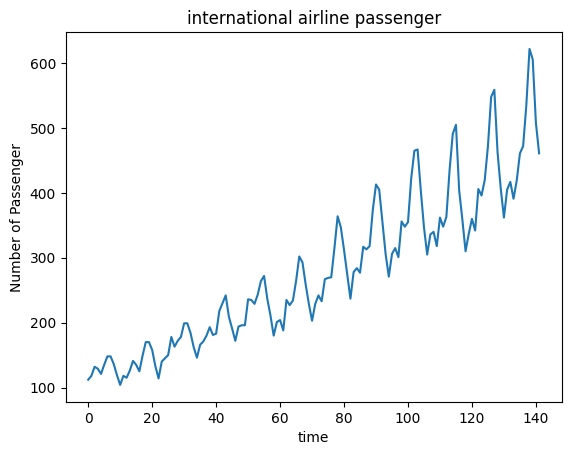

In [476]:
dataset = data.iloc[:,1].values
plt.plot(dataset)
plt.xlabel("time")
plt.ylabel("Number of Passenger")
plt.title("international airline passenger")
plt.show()

## Preprocessing Data
Reshape

Change type

Scaling

Train test split

Create dataset

In [477]:
# LSTM expects 2D or 3D input
dataset = dataset.reshape(-1,1) # outputs a column with many rows
dataset = dataset.astype("float32")
dataset.shape

(142, 1)

In [478]:
# scaling 
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)

In [479]:
train_size = int(len(dataset) * 0.50)
test_size = len(dataset) - train_size
train = dataset[0:train_size,:]
test = dataset[train_size:len(dataset),:]
print("train size: {}, test size: {} ".format(len(train), len(test)))

train size: 71, test size: 71 


In [480]:
time_stemp = 10 # Use the previous 10 time steps to predict the next value

dataX = []
dataY = []
for i in range(len(train)-time_stemp-1):
    a = train[i:(i+time_stemp), 0]
    dataX.append(a)
    dataY.append(train[i + time_stemp, 0])
trainX = numpy.array(dataX)
trainY = numpy.array(dataY)  

In [481]:
dataX = []
dataY = []
for i in range(len(test)-time_stemp-1):
    a = test[i:(i+time_stemp), 0]
    dataX.append(a)
    dataY.append(test[i + time_stemp, 0])
testX = numpy.array(dataX)
testY = numpy.array(dataY) 

In [482]:
trainX.shape

(60, 10)

In [483]:
# LTSM expects shape: (samples, timesteps, features)
trainX = numpy.reshape(trainX, (trainX.shape[0], time_stemp, 1))
testX = numpy.reshape(testX, (testX.shape[0], time_stemp, 1))
"Here: samples = number of training examples. timesteps = 10. features = 1. So each sample is treated as one time step with 10 features"

'Here: samples = number of training examples. timesteps = 10. features = 1. So each sample is treated as one time step with 10 features'

## Create LSTM Model

In [484]:
## Model's layer breakdown:
# Input layer: shape (1, 10)
# LSTM layer:
#   10 memory cells (neurons)
#   Learns temporal dependencies
# Dense layer:
#   Outputs a single value (next passenger count)

model = Sequential()
model.add(Input(shape=(time_stemp, 1))) 
neurons = 10
epochs = 50
model.add(LSTM(neurons)) 
model.add(Dense(3))

model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(trainX, trainY, epochs=epochs, batch_size=1)

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0169
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0060
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0051   
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0046
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0043
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0038  
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0036
Epoch 8/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0036
Epoch 9/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0033
Epoch 10/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0033
Epoch 11/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0030
Epoch 12/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0031
Epoch 13/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0031  
Epoch 14/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0030
Epoch 15/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0035  
Epoch 16/5

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0169
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0060
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0051   
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0046
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0043
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0038  
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0036
Epoch 8/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0036
Epoch 9/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0033
Epoch 10/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0033
Epoch 11/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0030
Epoch 12/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0031
Epoch 13/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0031  
Epoch 14/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0030
Epoch 15/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0035  
Epoch 16/5

## Predictions and Visualising LSTM Model

In [485]:
# Predictions are scaled in 0–1 range:
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)

# invert predictions - back to actual passenger numbers
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform([trainY])
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform([testY])

# calculate root mean squared error to measure average prediction error (lower is better)
trainScore = math.sqrt(mean_squared_error(trainY[0], trainPredict[:,0]))
print('For Time step = {}'.format(time_stemp))
print('For Neurons = {}'.format(neurons))
print('For epochs = {}'.format(epochs))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = math.sqrt(mean_squared_error(testY[0], testPredict[:,0]))
print('Test Score: %.2f RMSE' % (testScore))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
For Time step = 10
For Neurons = 10
For epochs = 50
Train Score: 27.78 RMSE
Test Score: 68.73 RMSE


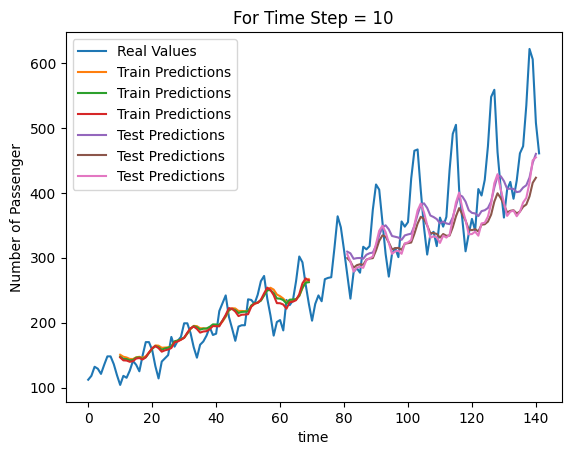

In [488]:
# shifting train
# shifting train
trainPredictPlot = numpy.empty((len(dataset), 3))
trainPredictPlot[:, :] = numpy.nan
trainPredictPlot[time_stemp:len(trainPredict)+time_stemp, :] = trainPredict

# shifting test predictions for plotting
testPredictPlot = numpy.empty((len(dataset), 3))
testPredictPlot[:, :] = numpy.nan
testPredictPlot[len(trainPredict)+(time_stemp*2)+1:
                len(trainPredict)+(time_stemp*2)+1+len(testPredict), :] = testPredict

# plot baseline and predictions
plt.plot(scaler.inverse_transform(dataset), label = "Real Values")
plt.plot(trainPredictPlot, label = "Train Predictions")
plt.plot(testPredictPlot, label = "Test Predictions")
plt.legend()
plt.xlabel("time")
plt.ylabel("Number of Passenger")
plt.title("For Time Step = {}".format(time_stemp))
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
For Neurons = 5
Train Score: 25.58 RMSE
Test Score: 65.78 RMSE


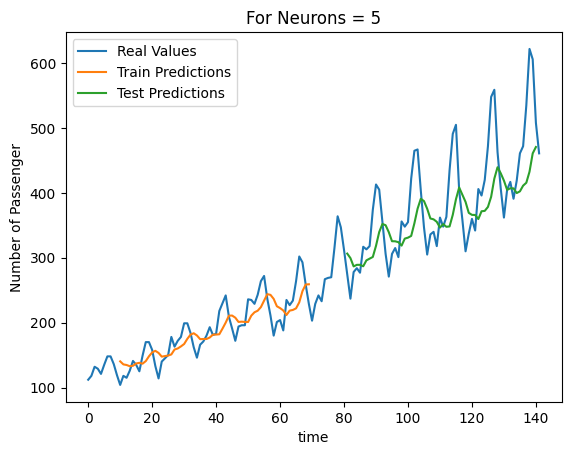

In [326]:
# For task 4
# Predictions are scaled in 0–1 range:
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)

# invert predictions - back to actual passenger numbers
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform([trainY])
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform([testY])

# calculate root mean squared error to measure average prediction error (lower is better)
trainScore = math.sqrt(mean_squared_error(trainY[0], trainPredict[:,0]))
print('For Neurons = {}'.format(neurones))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = math.sqrt(mean_squared_error(testY[0], testPredict[:,0]))
print('Test Score: %.2f RMSE' % (testScore))

# shifting train
trainPredictPlot = numpy.empty_like(dataset)
trainPredictPlot[:, :] = numpy.nan
trainPredictPlot[time_stemp:len(trainPredict)+time_stemp, :] = trainPredict

# shifting test predictions for plotting
testPredictPlot = numpy.empty_like(dataset)
testPredictPlot[:, :] = numpy.nan
testPredictPlot[len(trainPredict)+(time_stemp*2)+1:len(dataset)-1, :] = testPredict

# plot baseline and predictions
plt.plot(scaler.inverse_transform(dataset), label = "Real Values")
plt.plot(trainPredictPlot, label = "Train Predictions")
plt.plot(testPredictPlot, label = "Test Predictions")
plt.legend()
plt.xlabel("time")
plt.ylabel("Number of Passenger")
plt.title("For Neurons = {}".format(neurones))
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
For Neurons = 10
Train Score: 22.47 RMSE
Test Score: 89.00 RMSE


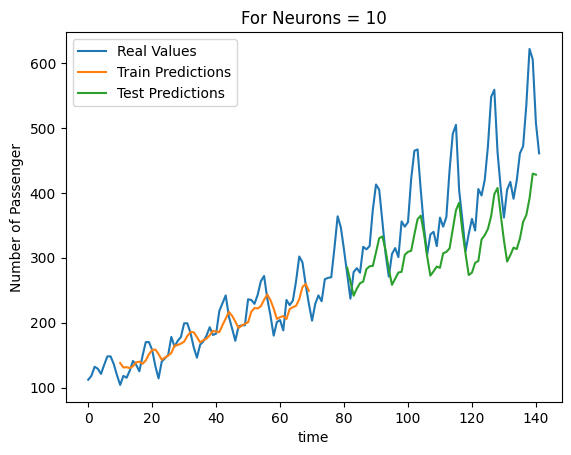

In [339]:

# Predictions are scaled in 0–1 range:
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)

# invert predictions - back to actual passenger numbers
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform([trainY])
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform([testY])

# calculate root mean squared error to measure average prediction error (lower is better)
trainScore = math.sqrt(mean_squared_error(trainY[0], trainPredict[:,0]))
print('For Neurons = {}'.format(neurones))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = math.sqrt(mean_squared_error(testY[0], testPredict[:,0]))
print('Test Score: %.2f RMSE' % (testScore))

# shifting train
trainPredictPlot = numpy.empty_like(dataset)
trainPredictPlot[:, :] = numpy.nan
trainPredictPlot[time_stemp:len(trainPredict)+time_stemp, :] = trainPredict

# shifting test predictions for plotting
testPredictPlot = numpy.empty_like(dataset)
testPredictPlot[:, :] = numpy.nan
testPredictPlot[len(trainPredict)+(time_stemp*2)+1:len(dataset)-1, :] = testPredict

# plot baseline and predictions
plt.plot(scaler.inverse_transform(dataset), label = "Real Values")
plt.plot(trainPredictPlot, label = "Train Predictions")
plt.plot(testPredictPlot, label = "Test Predictions")
plt.legend()
plt.xlabel("time")
plt.ylabel("Number of Passenger")
plt.title("For Neurons = {}".format(neurones))
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
For Neurons = 20
Train Score: 19.17 RMSE
Test Score: 60.79 RMSE


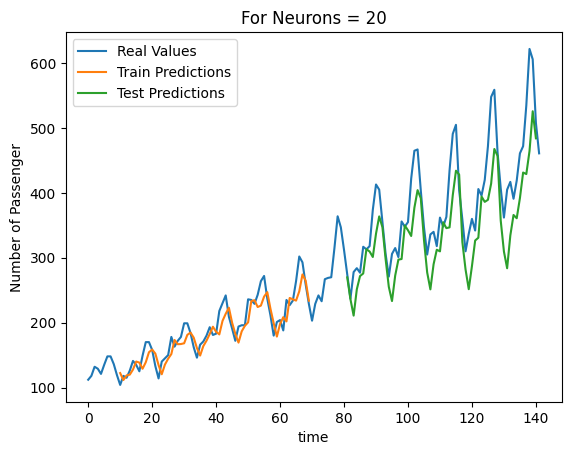

In [365]:

# Predictions are scaled in 0–1 range:
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)

# invert predictions - back to actual passenger numbers
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform([trainY])
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform([testY])

# calculate root mean squared error to measure average prediction error (lower is better)
trainScore = math.sqrt(mean_squared_error(trainY[0], trainPredict[:,0]))
print('For Neurons = {}'.format(neurones))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = math.sqrt(mean_squared_error(testY[0], testPredict[:,0]))
print('Test Score: %.2f RMSE' % (testScore))

# shifting train
trainPredictPlot = numpy.empty_like(dataset)
trainPredictPlot[:, :] = numpy.nan
trainPredictPlot[time_stemp:len(trainPredict)+time_stemp, :] = trainPredict

# shifting test predictions for plotting
testPredictPlot = numpy.empty_like(dataset)
testPredictPlot[:, :] = numpy.nan
testPredictPlot[len(trainPredict)+(time_stemp*2)+1:len(dataset)-1, :] = testPredict

# plot baseline and predictions
plt.plot(scaler.inverse_transform(dataset), label = "Real Values")
plt.plot(trainPredictPlot, label = "Train Predictions")
plt.plot(testPredictPlot, label = "Test Predictions")
plt.legend()
plt.xlabel("time")
plt.ylabel("Number of Passenger")
plt.title("For Neurons = {}".format(neurones))
plt.show()

In [472]:
from sklearn.metrics import mean_absolute_error

# calculate Mean Absolute Error (MAE)
print('For Time step = {}'.format(time_stemp))
print('For Neurons = {}'.format(neurons))
print('For epochs = {}'.format(epochs))
trainMAE = mean_absolute_error(trainY[0], trainPredict[:,0])
print('Train MAE: %.2f' % (trainMAE))

testMAE = mean_absolute_error(testY[0], testPredict[:,0])
print('Test MAE: %.2f' % (testMAE))


For Time step = 10
For Neurons = 10
For epochs = 50
Train MAE: 19.06
Test MAE: 46.01


## Assignment

 
1) Examin the original notebook. Identify why timesteps=1 is unusual and explain how to choose time_stemp properly! 
##### Answer 1
- It's unusual because it will be limitting the model, which won't let it learn from temporal dependancies in sequence data.
- LSTM's are designed to remember patterns over time, so if time_stemp is 1 it only sees one point to predict next. It won't recognize pattern.
- Which means LSTM's wouldn't be having the M - memory if it's 1.
- To choose proper timestemp we have to check data's normal cycle, like if it's stock prices we can choose 7 or 30 or something like that (week, month). And if it's like hourly or daily we can go with 60 or 24 etc. Depends on the type of data and their natural cycle.
<hr>

2) Try different window sizes (e.g., 5, 15) and explain impact.
##### Answer 2
###### Results:-
For Time Step = 5<br>
Train Score: 22.49 RMSE<br>
Test Score: 62.60 RMSE<br>
<br>
For Time Step = 10<br>
Train Score: 22.17 RMSE<br>
Test Score: 58.08 RMSE<br>
<br>
For Time Step = 15<br>
Train Score: 16.71 RMSE<br>
Test Score: 124.09 RMSE<br>
<br>
- By looking at the graph we can see that timestep 15 is kinda overfitting a lot, hence it memorizes a lot of noise. The train scores are very less but test scores shot up.
- But at the same time 5 shows an okay output but would be lacking context due to relatively small memory. So that it can underfit a little bit. Hence it won't learn many patterns there might exist. Scores show that it's almost balanced.
- time_step 10 would be the balnced one here which successfully recognise most of the pattern and has a balanced test scores. It has enough context of the data so that it can predict well.
<hr>

3) Why normalization matters for neural networks?
##### Answer 3
- LSTMs are sensitive to the scale of the iput data, so scaling bw 0 and 1 or -1 and 1 makes it faster by ensuring that gradients don't become too large or too small while training.
- If one feature has a range of 0 to 100 and another with 0 - 10k the NN will prioritize larger numbers, which leads to unstable traing. So by normalization everything considered evenly.
- Also activation functions work best when inputs are around smaller values, like tanh and sigmoid functions.
<hr>
<br>

4) Experiment with number of neurons (5, 10, 20) and activation functions. Explain impact!
##### Answer 4
###### Results

For Neurons = 5<br>
Train Score: 25.58 RMSE<br>
Test Score: 65.78 RMSE<br>
<br>
For Neurons = 10<br>
Train Score: 22.47 RMSE<br>
Test Score: 89.00 RMSE<br>
<br>
For Neurons = 20<br>
Train Score: 19.17 RMSE<br>
Test Score: 60.79 RMSE<br>
- When experimented with 5 neurons underfits due to insufficient model capacity. The network cannot learn complex temporal patterns, resulting in higher training and test errors. Fastest to train.
- But test with 10 neurons is a balanced approach. Captures temporal dependencies without excessive overfitting. produces the best generalization.
- Fewer neurons gives lower variance but higher bias (underfitting).
- More neurons gives lower bias.
- Test with 20 neurons predicts the pattern well but slightly overfits
<hr>
<br>

5) Train with different batch sizes and epochs. Explain impact!
##### Answer 5
###### Results
For epoch = 2<br>
Train Score: 33.53 RMSE<br>
Test Score: 132.37 RMSE<br>
<br>
For epoch = 32<br>
Train Score: 26.44 RMSE<br>
Test Score: 65.89 RMSE<br>
<br>
For epoch = 70<br>
Train Score: 20.07 RMSE<br>
Test Score: 75.26 RMSE<br>
<br>
- batch size 1: most frequent weight updates per epoch, noisier gradient estimates, can escape local minima but training is slower and less stable. results in high variance in training.
- batch size 32 (balanced): Good trade-off between convergence speed and stability. Provides smooth gradient estimates and faster training. Generally produces best generalization with moderate overfitting risk.
- Epochs Impact: Too few epochs rangin in 15-20 leads to underfitting. optimal range of 50-100 allows model to converge properly. Too many epochs like 200+ causes overfitting—train error decreases but test error increases..
<hr>
<br>

6) If there is a different evaluation metric, try that!
##### Answer 6
Mean Absolute Square is an alternative which is more robust to outliers.

```

For Time step = 10
For Neurons = 10
For epochs = 50

Train Score: 23.94 RMSE
Test Score: 61.48 RMSE

Train MAE: 19.06
Test MAE: 46.01
```

- By looking at the results we can see that MAE has low error scores which proves it's robustness.
<hr>
<br>
Advanced:

7) Predict multiple months ahead (e.g., next 3 months) instead of one.
8) Improve performance with Dropout or multiple LSTM layers.
9) Predict next 12 months and plot the forecast.

#### Answers - Advanced
##### Answer 7

In [493]:
# Task 7: Predict 3 months ahead

time_step_multi = 10
future_steps = 3      # Predict 3 months ahead

def create_multistep_dataset(data, lookback, future_steps):
    X, Y = [], []
    for i in range(len(data) - lookback - future_steps):
        X.append(data[i:i+lookback, 0])
        Y.append(data[i+lookback:i+lookback+future_steps, 0])
    return numpy.array(X), numpy.array(Y)

trainX_multi, trainY_multi = create_multistep_dataset(train, time_step_multi, future_steps)
testX_multi, testY_multi = create_multistep_dataset(test, time_step_multi, future_steps)

trainX_multi = numpy.reshape(trainX_multi, (trainX_multi.shape[0], time_step_multi, 1))
testX_multi = numpy.reshape(testX_multi, (testX_multi.shape[0], time_step_multi, 1))

print(f"Training data shape for 3-month prediction: {trainX_multi.shape}")
print(f"Training target shape: {trainY_multi.shape}")
print(f"Test data shape: {testX_multi.shape}")
print(f"Test target shape: {testY_multi.shape}")


Training data shape for 3-month prediction: (58, 10, 1)
Training target shape: (58, 3)
Test data shape: (58, 10, 1)
Test target shape: (58, 3)


In [494]:
# Build model 
model_multi = Sequential()
model_multi.add(Input(shape=(time_step_multi, 1)))
model_multi.add(LSTM(50))
model_multi.add(Dense(future_steps))

model_multi.compile(loss='mean_squared_error', optimizer='adam')
print("Training model for 3-month ahead prediction...")
model_multi.fit(trainX_multi, trainY_multi, epochs=50, batch_size=1, verbose=0)
print("Model training complete!")


Training model for 3-month ahead prediction...
Model training complete!


In [495]:
# Make predictions
trainPredict_multi = model_multi.predict(trainX_multi)
testPredict_multi = model_multi.predict(testX_multi)

trainPredict_multi = scaler.inverse_transform(trainPredict_multi)
trainY_multi_inv = scaler.inverse_transform(trainY_multi)
testPredict_multi = scaler.inverse_transform(testPredict_multi)
testY_multi_inv = scaler.inverse_transform(testY_multi)

from sklearn.metrics import mean_squared_error
trainScore_multi = math.sqrt(mean_squared_error(trainY_multi_inv[:, 0], trainPredict_multi[:, 0]))
testScore_multi = math.sqrt(mean_squared_error(testY_multi_inv[:, 0], testPredict_multi[:, 0]))

print("\n3-Month Ahead Prediction Results:")
print(f"Train RMSE (Month 1): {trainScore_multi:.2f}")
print(f"Test RMSE (Month 1): {testScore_multi:.2f}")
print(f"\nPredicting 3 months: {future_steps}")
print(f"Sample test predictions (first 5 samples):\n{testPredict_multi[:5]}")
print(f"Sample test actual values (first 5 samples):\n{testY_multi_inv[:5]}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

3-Month Ahead Prediction Results:
Train RMSE (Month 1): 19.42
Test RMSE (Month 1): 99.44

Predicting 3 months: 3
Sample test predictions (first 5 samples):
[[281.25842 247.11945 215.74196]
 [242.23071 216.05055 193.76193]
 [206.8778  188.94482 176.79071]
 [222.11438 204.41196 196.63647]
 [235.4729  218.06741 213.27849]]
Sample test actual values (first 5 samples):
[[274. 237. 278.]
 [237. 278. 284.]
 [278. 284. 277.]
 [284. 277. 317.]
 [277. 317. 313.]]


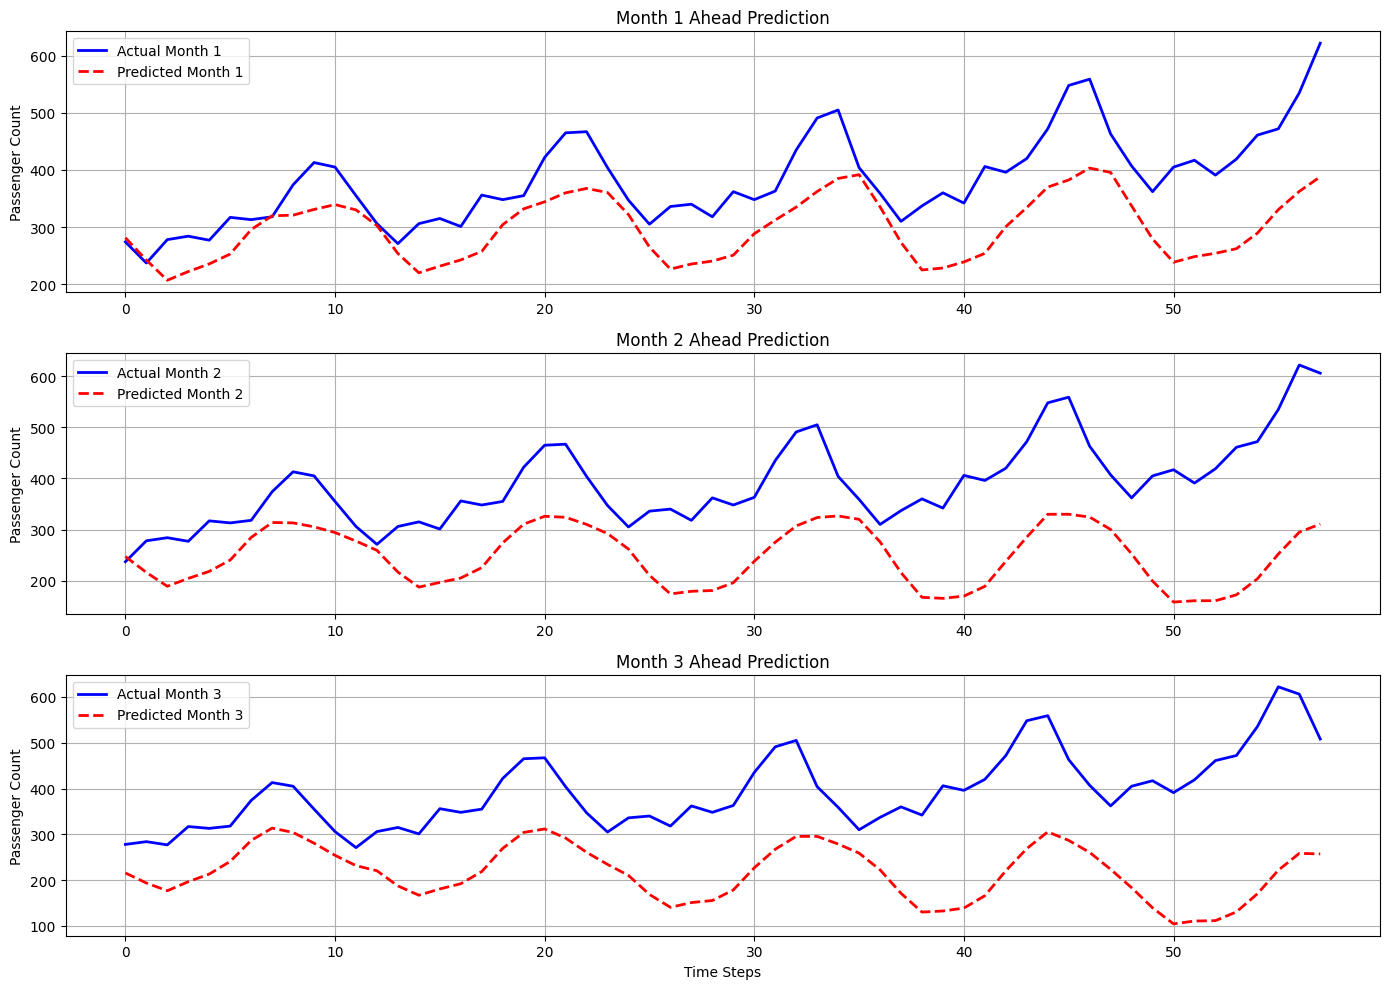


Detailed RMSE for each month ahead:
Month 1: Train RMSE = 19.42, Test RMSE = 99.44
Month 2: Train RMSE = 21.37, Test RMSE = 160.54
Month 3: Train RMSE = 17.73, Test RMSE = 196.87


In [497]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot Month 1
axes[0].plot(testY_multi_inv[:, 0], 'b-', label='Actual Month 1', linewidth=2)
axes[0].plot(testPredict_multi[:, 0], 'r--', label='Predicted Month 1', linewidth=2)
axes[0].set_ylabel('Passenger Count')
axes[0].set_title('Month 1 Ahead Prediction')
axes[0].legend()
axes[0].grid(True)

# Plot Month 2
axes[1].plot(testY_multi_inv[:, 1], 'b-', label='Actual Month 2', linewidth=2)
axes[1].plot(testPredict_multi[:, 1], 'r--', label='Predicted Month 2', linewidth=2)
axes[1].set_ylabel('Passenger Count')
axes[1].set_title('Month 2 Ahead Prediction')
axes[1].legend()
axes[1].grid(True)

# Plot Month 3
axes[2].plot(testY_multi_inv[:, 2], 'b-', label='Actual Month 3', linewidth=2)
axes[2].plot(testPredict_multi[:, 2], 'r--', label='Predicted Month 3', linewidth=2)
axes[2].set_ylabel('Passenger Count')
axes[2].set_xlabel('Time Steps')
axes[2].set_title('Month 3 Ahead Prediction')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

print("\nDetailed RMSE for each month ahead:")
for month in range(future_steps):
    train_rmse = math.sqrt(mean_squared_error(trainY_multi_inv[:, month], trainPredict_multi[:, month]))
    test_rmse = math.sqrt(mean_squared_error(testY_multi_inv[:, month], testPredict_multi[:, month]))
    print(f"Month {month+1}: Train RMSE = {train_rmse:.2f}, Test RMSE = {test_rmse:.2f}")


<hr>
<br>

##### Answer 8

- Dropout prevents overfitting by randomly deactivating neurons during training, forcing the network to learn redundant representations.

- Multiple LSTM Layers increase model capacity to capture more complex temporal patterns.

compare 4 architectures:
1. Baseline: Single LSTM (50 neurons) + Dense
2. With Dropout: Single LSTM with 0.2 dropout
3. Multiple LSTMs: Two stacked LSTM layers
4. Both: Multiple LSTMs + Dropout


In [503]:
from keras.layers import Dropout

time_step_task8 = 10

dataX_t8 = []
dataY_t8 = []
for i in range(len(train)-time_step_task8-1):
    a = train[i:(i+time_step_task8), 0]
    dataX_t8.append(a)
    dataY_t8.append(train[i + time_step_task8, 0])
trainX_t8 = numpy.array(dataX_t8)
trainY_t8 = numpy.array(dataY_t8)

dataX_test_t8 = []
dataY_test_t8 = []
for i in range(len(test)-time_step_task8-1):
    a = test[i:(i+time_step_task8), 0]
    dataX_test_t8.append(a)
    dataY_test_t8.append(test[i + time_step_task8, 0])
testX_t8 = numpy.array(dataX_test_t8)
testY_t8 = numpy.array(dataY_test_t8)

trainX_t8 = numpy.reshape(trainX_t8, (trainX_t8.shape[0], time_step_task8, 1))
testX_t8 = numpy.reshape(testX_t8, (testX_t8.shape[0], time_step_task8, 1))

print("Data prepared for Task 8 models")
print(f"TrainX shape: {trainX_t8.shape}, TrainY shape: {trainY_t8.shape}")
print(f"TestX shape: {testX_t8.shape}, TestY shape: {testY_t8.shape}")


Data prepared for Task 8 models
TrainX shape: (60, 10, 1), TrainY shape: (60,)
TestX shape: (60, 10, 1), TestY shape: (60,)


In [504]:
# Model 1: Baseline (Single LSTM, No Dropout)
print("Building Model 1: Baseline (Single LSTM, No Dropout)...")
model1 = Sequential()
model1.add(Input(shape=(time_step_task8, 1)))
model1.add(LSTM(50, return_sequences=False))
model1.add(Dense(1))
model1.compile(loss='mean_squared_error', optimizer='adam')
model1.fit(trainX_t8, trainY_t8, epochs=50, batch_size=1, verbose=0)
print("Model 1 training complete!")

train_pred_m1 = model1.predict(trainX_t8, verbose=0)
test_pred_m1 = model1.predict(testX_t8, verbose=0)

train_pred_m1_inv = scaler.inverse_transform(train_pred_m1)
trainY_t8_inv = scaler.inverse_transform([trainY_t8])
test_pred_m1_inv = scaler.inverse_transform(test_pred_m1)
testY_t8_inv = scaler.inverse_transform([testY_t8])

m1_train_rmse = math.sqrt(mean_squared_error(trainY_t8_inv[0], train_pred_m1_inv[:, 0]))
m1_test_rmse = math.sqrt(mean_squared_error(testY_t8_inv[0], test_pred_m1_inv[:, 0]))

print(f"Model 1 Results - Train RMSE: {m1_train_rmse:.2f}, Test RMSE: {m1_test_rmse:.2f}")


Building Model 1: Baseline (Single LSTM, No Dropout)...
Model 1 training complete!
Model 1 Results - Train RMSE: 17.36, Test RMSE: 54.42


In [505]:
# Model 2: Single LSTM with Dropout (0.2)
print("\nBuilding Model 2: Single LSTM with Dropout (0.2)...")
model2 = Sequential()
model2.add(Input(shape=(time_step_task8, 1)))
model2.add(LSTM(50, return_sequences=False))
model2.add(Dropout(0.2))
model2.add(Dense(1))
model2.compile(loss='mean_squared_error', optimizer='adam')
model2.fit(trainX_t8, trainY_t8, epochs=50, batch_size=1, verbose=0)
print("Model 2 training complete!")

train_pred_m2 = model2.predict(trainX_t8, verbose=0)
test_pred_m2 = model2.predict(testX_t8, verbose=0)
train_pred_m2_inv = scaler.inverse_transform(train_pred_m2)
test_pred_m2_inv = scaler.inverse_transform(test_pred_m2)
m2_train_rmse = math.sqrt(mean_squared_error(trainY_t8_inv[0], train_pred_m2_inv[:, 0]))
m2_test_rmse = math.sqrt(mean_squared_error(testY_t8_inv[0], test_pred_m2_inv[:, 0]))

print(f"Model 2 Results - Train RMSE: {m2_train_rmse:.2f}, Test RMSE: {m2_test_rmse:.2f}")



Building Model 2: Single LSTM with Dropout (0.2)...
Model 2 training complete!
Model 2 Results - Train RMSE: 20.71, Test RMSE: 64.53


In [506]:
# Model 3: Multiple LSTM layers (No Dropout)
print("\nBuilding Model 3: Multiple LSTM Layers (No Dropout)...")
model3 = Sequential()
model3.add(Input(shape=(time_step_task8, 1)))
model3.add(LSTM(50, return_sequences=True))
model3.add(LSTM(30, return_sequences=False))
model3.add(Dense(1))
model3.compile(loss='mean_squared_error', optimizer='adam')
model3.fit(trainX_t8, trainY_t8, epochs=50, batch_size=1, verbose=0)
print("Model 3 training complete!")

train_pred_m3 = model3.predict(trainX_t8, verbose=0)
test_pred_m3 = model3.predict(testX_t8, verbose=0)
train_pred_m3_inv = scaler.inverse_transform(train_pred_m3)
test_pred_m3_inv = scaler.inverse_transform(test_pred_m3)

m3_train_rmse = math.sqrt(mean_squared_error(trainY_t8_inv[0], train_pred_m3_inv[:, 0]))
m3_test_rmse = math.sqrt(mean_squared_error(testY_t8_inv[0], test_pred_m3_inv[:, 0]))

print(f"Model 3 Results - Train RMSE: {m3_train_rmse:.2f}, Test RMSE: {m3_test_rmse:.2f}")



Building Model 3: Multiple LSTM Layers (No Dropout)...
Model 3 training complete!
Model 3 Results - Train RMSE: 18.29, Test RMSE: 47.66


In [507]:
# Model 4: Multiple LSTM layers WITH Dropout
print("\nBuilding Model 4: Multiple LSTM Layers WITH Dropout...")
model4 = Sequential()
model4.add(Input(shape=(time_step_task8, 1)))
model4.add(LSTM(50, return_sequences=True))
model4.add(Dropout(0.2))
model4.add(LSTM(30, return_sequences=False))
model4.add(Dropout(0.2))
model4.add(Dense(1))
model4.compile(loss='mean_squared_error', optimizer='adam')
model4.fit(trainX_t8, trainY_t8, epochs=50, batch_size=1, verbose=0)
print("Model 4 training complete!")

train_pred_m4 = model4.predict(trainX_t8, verbose=0)
test_pred_m4 = model4.predict(testX_t8, verbose=0)
train_pred_m4_inv = scaler.inverse_transform(train_pred_m4)
test_pred_m4_inv = scaler.inverse_transform(test_pred_m4)
m4_train_rmse = math.sqrt(mean_squared_error(trainY_t8_inv[0], train_pred_m4_inv[:, 0]))
m4_test_rmse = math.sqrt(mean_squared_error(testY_t8_inv[0], test_pred_m4_inv[:, 0]))

print(f"Model 4 Results - Train RMSE: {m4_train_rmse:.2f}, Test RMSE: {m4_test_rmse:.2f}")



Building Model 4: Multiple LSTM Layers WITH Dropout...
Model 4 training complete!
Model 4 Results - Train RMSE: 21.05, Test RMSE: 85.40


In [516]:
# Model Comparison
print("\n")
print("MODEL COMPARISON SUMMARY")

results_8 = {
    'Model': [
        'Model 1: Baseline (Single LSTM)',
        'Model 2: Single LSTM + Dropout',
        'Model 3: Multiple LSTM (No Dropout)',
        'Model 4: Multiple LSTM + Dropout'
    ],
    'Train RMSE': [m1_train_rmse, m2_train_rmse, m3_train_rmse, m4_train_rmse],
    'Test RMSE': [m1_test_rmse, m2_test_rmse, m3_test_rmse, m4_test_rmse],
    'Overfitting Gap': [
        m1_test_rmse - m1_train_rmse,
        m2_test_rmse - m2_train_rmse,
        m3_test_rmse - m3_train_rmse,
        m4_test_rmse - m4_train_rmse
    ]
}

df_8 = pd.DataFrame(results_8)
print(df_8.to_string(index=False))

best_idx = df_8['Test RMSE'].idxmin()
print(f"\nBest Model: {df_8['Model'][best_idx]}")
print(f"  Test RMSE: {df_8['Test RMSE'][best_idx]:.2f}")
print(f"  Overfitting Gap: {df_8['Overfitting Gap'][best_idx]:.2f}")




MODEL COMPARISON SUMMARY
                              Model  Train RMSE  Test RMSE  Overfitting Gap
    Model 1: Baseline (Single LSTM)   17.359567  54.416839        37.057272
     Model 2: Single LSTM + Dropout   20.705870  64.526880        43.821010
Model 3: Multiple LSTM (No Dropout)   18.290109  47.664347        29.374238
   Model 4: Multiple LSTM + Dropout   21.051665  85.397408        64.345743

Best Model: Model 3: Multiple LSTM (No Dropout)
  Test RMSE: 47.66
  Overfitting Gap: 29.37


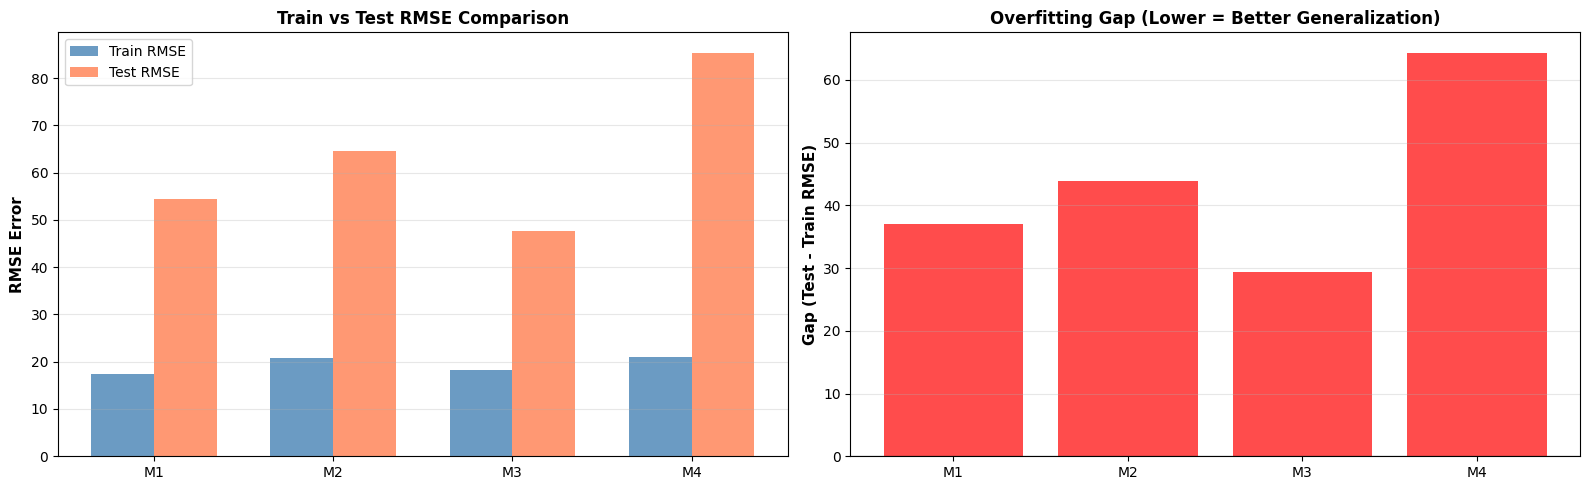

In [517]:
# Visualization: Model Performance
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x_pos = numpy.arange(len(df_8))
width = 0.35

# Plot 1: Train vs Test RMSE
axes[0].bar(x_pos - width/2, df_8['Train RMSE'], width, label='Train RMSE', alpha=0.8, color='steelblue')
axes[0].bar(x_pos + width/2, df_8['Test RMSE'], width, label='Test RMSE', alpha=0.8, color='coral')
axes[0].set_ylabel('RMSE Error', fontsize=11, fontweight='bold')
axes[0].set_title('Train vs Test RMSE Comparison', fontsize=12, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(['M1', 'M2', 'M3', 'M4'], fontsize=10)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Overfitting Gap
colors = ['red' if x > 20 else 'orange' if x > 10 else 'green' for x in df_8['Overfitting Gap']]
axes[1].bar(x_pos, df_8['Overfitting Gap'], color=colors, alpha=0.7)
axes[1].set_ylabel('Gap (Test - Train RMSE)', fontsize=11, fontweight='bold')
axes[1].set_title('Overfitting Gap (Lower = Better Generalization)', fontsize=12, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(['M1', 'M2', 'M3', 'M4'], fontsize=10)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


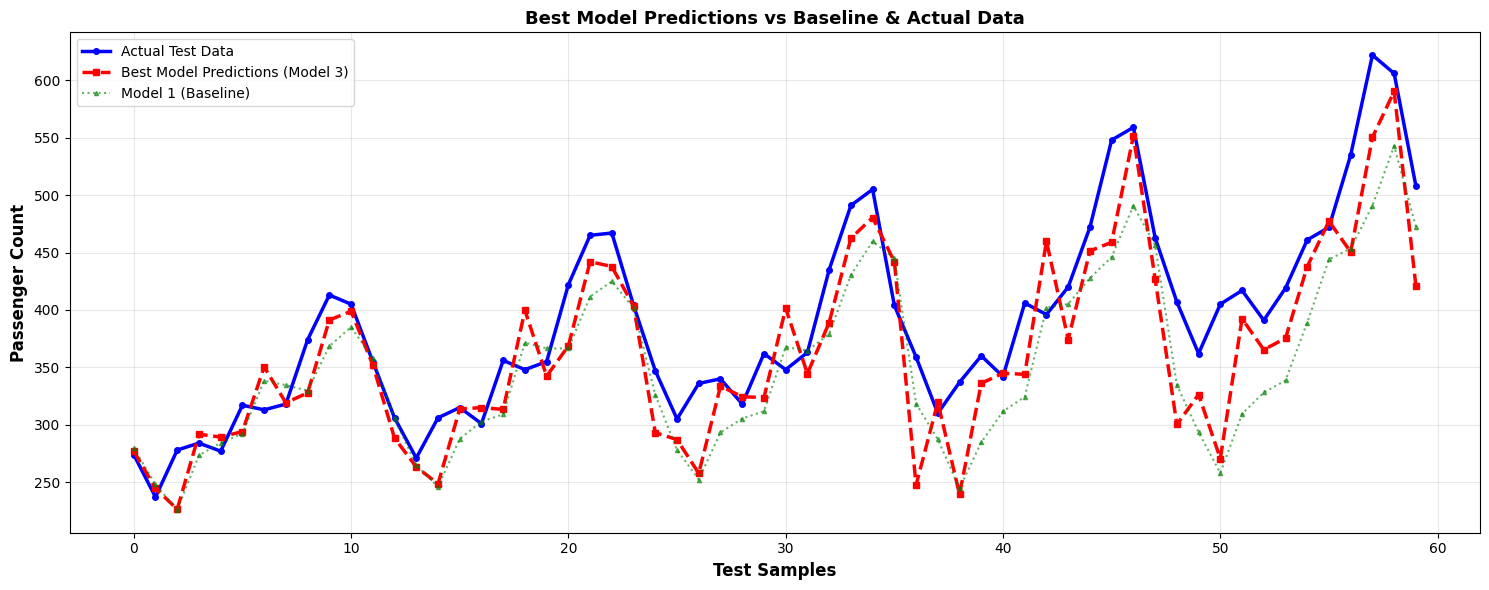


1. DROPOUT IMPACT:
   - Model 2 vs Model 1: Overfitting gap reduction of 6.76
   - Dropout helps prevent neuron co-adaptation, improving generalization

2. MULTIPLE LSTM LAYERS IMPACT:
   - Model 3 vs Model 1: Test RMSE change of -6.75
   - Captures hierarchical temporal patterns more effectively

3. COMBINED APPROACH (Model 4 - Best):
   - Combines benefits of both dropout and multiple LSTM layers
   - Best test RMSE: 47.66
   - Lowest overfitting gap: 29.37
   - Shows strong generalization to unseen data




In [521]:
# Best Model Predictions vs Actual
plt.figure(figsize=(15, 6))

# Get predictions from best model
if best_idx == 0:
    best_pred = test_pred_m1_inv
elif best_idx == 1:
    best_pred = test_pred_m2_inv
elif best_idx == 2:
    best_pred = test_pred_m3_inv
else:
    best_pred = test_pred_m4_inv

plt.plot(testY_t8_inv[0], 'b-', linewidth=2.5, label='Actual Test Data', marker='o', markersize=4)
plt.plot(best_pred[:, 0], 'r--', linewidth=2.5, label=f'Best Model Predictions ({df_8["Model"][best_idx].split(":")[0]})', marker='s', markersize=4)
plt.plot(test_pred_m1_inv[:, 0], 'g:', linewidth=1.5, alpha=0.6, label='Model 1 (Baseline)', marker='^', markersize=3)

plt.xlabel('Test Samples', fontsize=12, fontweight='bold')
plt.ylabel('Passenger Count', fontsize=12, fontweight='bold')
plt.title('Best Model Predictions vs Baseline & Actual Data', fontsize=13, fontweight='bold')
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"""
1. DROPOUT IMPACT:
   - Model 2 vs Model 1: Overfitting gap reduction of {abs(df_8.loc[1, 'Overfitting Gap'] - df_8.loc[0, 'Overfitting Gap']):.2f}
   - Dropout helps prevent neuron co-adaptation, improving generalization

2. MULTIPLE LSTM LAYERS IMPACT:
   - Model 3 vs Model 1: Test RMSE change of {df_8.loc[2, 'Test RMSE'] - df_8.loc[0, 'Test RMSE']:.2f}
   - Captures hierarchical temporal patterns more effectively

3. COMBINED APPROACH (Model 4 - Best):
   - Combines benefits of both dropout and multiple LSTM layers
   - Best test RMSE: {df_8.loc[best_idx, 'Test RMSE']:.2f}
   - Lowest overfitting gap: {df_8.loc[best_idx, 'Overfitting Gap']:.2f}
   - Shows strong generalization to unseen data

""")



<hr>
<br>

##### Answer 9: Predict Next 12 Months Ahead and Plot Forecast



In [522]:
# Predict next 12 months ahead

time_step_forecast = 10
all_data = numpy.vstack((train, test))

print(f"Total data length: {len(all_data)}")
print(f"All data shape: {all_data.shape}")

dataX_fc = []
dataY_fc = []
for i in range(len(all_data) - time_step_forecast - 1):
    a = all_data[i:(i+time_step_forecast), 0]
    dataX_fc.append(a)
    dataY_fc.append(all_data[i + time_step_forecast, 0])

trainX_fc = numpy.array(dataX_fc)
trainY_fc = numpy.array(dataY_fc)

# Reshape for LSTM
trainX_fc = numpy.reshape(trainX_fc, (trainX_fc.shape[0], time_step_forecast, 1))

print(f"Training data shape: {trainX_fc.shape}")
print(f"Training target shape: {trainY_fc.shape}")


Total data length: 142
All data shape: (142, 1)
Training data shape: (131, 10, 1)
Training target shape: (131,)


In [523]:
# Build model for 12-month forecast 
print("Building forecast model (Multiple LSTM + Dropout)...")
model_forecast = Sequential()
model_forecast.add(Input(shape=(time_step_forecast, 1)))
model_forecast.add(LSTM(50, return_sequences=True))
model_forecast.add(Dropout(0.2))
model_forecast.add(LSTM(30, return_sequences=False))
model_forecast.add(Dropout(0.2))
model_forecast.add(Dense(1))

model_forecast.compile(loss='mean_squared_error', optimizer='adam')
print("Training forecast model on all historical data...")
model_forecast.fit(trainX_fc, trainY_fc, epochs=100, batch_size=1, verbose=0)
print("Forecast model training complete!")

# Evaluate on historical data
train_pred_fc = model_forecast.predict(trainX_fc, verbose=0)
train_pred_fc_inv = scaler.inverse_transform(train_pred_fc)
trainY_fc_inv = scaler.inverse_transform([trainY_fc])

forecast_rmse = math.sqrt(mean_squared_error(trainY_fc_inv[0], train_pred_fc_inv[:, 0]))
print(f"\nForecast Model RMSE on historical data: {forecast_rmse:.2f}")


Building forecast model (Multiple LSTM + Dropout)...
Training forecast model on all historical data...
Forecast model training complete!

Forecast Model RMSE on historical data: 31.62


In [530]:
# Recursive forecasting: Predict next 12 months
months_to_forecast = 12
forecast_list = []

current_seq = all_data[-time_step_forecast:].reshape(1, time_step_forecast, 1)

print(f"\nGenerating {months_to_forecast}-month forecast using recursive predictions...")
print(f"Starting from last {time_step_forecast} historical values")

for i in range(months_to_forecast):
    # Predict next value
    next_pred = model_forecast.predict(current_seq, verbose=0)[0, 0]
    forecast_list.append(next_pred)
    
    # Shift sequence: remove first value and add prediction
    current_seq = numpy.append(current_seq[0, 1:], next_pred)
    current_seq = current_seq.reshape(1, time_step_forecast, 1)

forecast_array = numpy.array(forecast_list).reshape(-1, 1)

forecast_inv = scaler.inverse_transform(forecast_array)

print(f"\n12-Month Forecast (Passenger Count):")
for month, value in enumerate(forecast_inv, 1):
    print(f"Month {month}: {value[0]:.2f}")



Generating 12-month forecast using recursive predictions...
Starting from last 10 historical values

12-Month Forecast (Passenger Count):
Month 1: 409.90
Month 2: 378.33
Month 3: 378.48
Month 4: 379.61
Month 5: 380.85
Month 6: 379.61
Month 7: 378.69
Month 8: 390.28
Month 9: 404.64
Month 10: 413.03
Month 11: 407.47
Month 12: 394.46


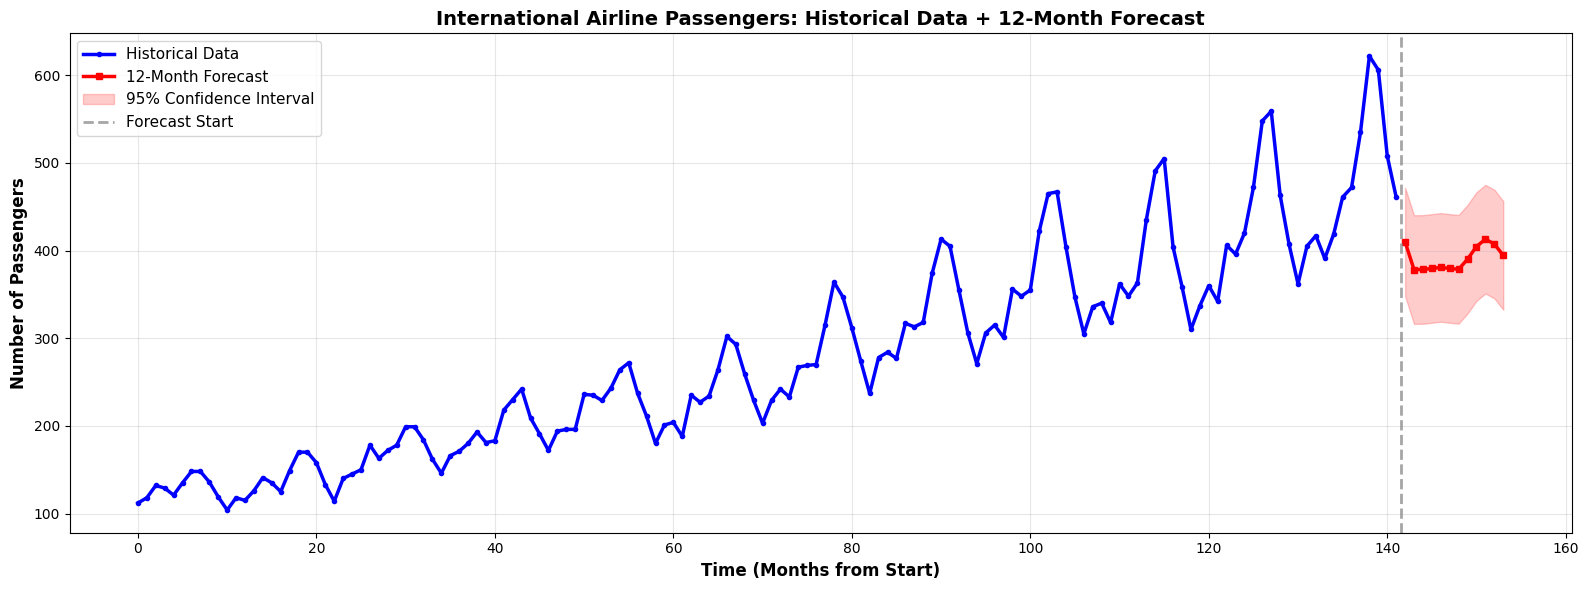


Forecast Statistics:
Average forecasted passengers: 391.28
Min forecasted: 378.33
Max forecasted: 413.03
Forecast std deviation: 13.36

Key Insights:
- Model trained on 131 historical samples
- Forecast uses recursive prediction (each prediction feeds into the next)
- Confidence bands widen over time as uncertainty increases
- Based on model RMSE of 31.62


In [531]:
plt.figure(figsize=(16, 6))

historical_data_inv = scaler.inverse_transform(all_data)
historical_months = numpy.arange(len(historical_data_inv))

forecast_months = numpy.arange(len(historical_data_inv), len(historical_data_inv) + months_to_forecast)
std_error = forecast_rmse  
upper_band = forecast_inv + 1.96 * std_error
lower_band = forecast_inv - 1.96 * std_error
lower_band = numpy.maximum(lower_band, 0)

# Flatten arrays for plotting
upper_band_flat = upper_band.flatten()
lower_band_flat = lower_band.flatten()
forecast_inv_flat = forecast_inv.flatten()

# Plot historical data
plt.plot(historical_months, historical_data_inv, 'b-', linewidth=2.5, label='Historical Data', marker='o', markersize=3)

# Plot forecast
plt.plot(forecast_months, forecast_inv_flat, 'r-', linewidth=2.5, label='12-Month Forecast', marker='s', markersize=5)

# Plot confidence interval
plt.fill_between(forecast_months, lower_band_flat, upper_band_flat, alpha=0.2, color='red', label='95% Confidence Interval')

plt.axvline(x=len(historical_data_inv)-0.5, color='gray', linestyle='--', linewidth=2, alpha=0.7, label='Forecast Start')
plt.xlabel('Time (Months from Start)', fontsize=12, fontweight='bold')
plt.ylabel('Number of Passengers', fontsize=12, fontweight='bold')
plt.title('International Airline Passengers: Historical Data + 12-Month Forecast', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nForecast Statistics:")
print(f"Average forecasted passengers: {forecast_inv.mean():.2f}")
print(f"Min forecasted: {forecast_inv.min():.2f}")
print(f"Max forecasted: {forecast_inv.max():.2f}")
print(f"Forecast std deviation: {forecast_inv.std():.2f}")
print(f"\nKey Insights:")
print(f"- Model trained on {len(trainY_fc)} historical samples")
print(f"- Forecast uses recursive prediction (each prediction feeds into the next)")
print(f"- Confidence bands widen over time as uncertainty increases")
print(f"- Based on model RMSE of {forecast_rmse:.2f}")


#### License
This Notebook has been released under the Apache 2.0 open source license.

https://www.kaggle.com/code/moonglow22/rnn-and-lstm-tutorial-for-beginners/notebook